# ViT-B/16 — WaRP-C (Optimised v2)
**Author:** Sayed Omar Aabid

---
### What changed from v1 and why

| Change | v1 | v2 (this notebook) |
|---|---|---|
| Normalisation | ImageNet stats | WaRP-C stats `WARP_MEAN / WARP_STD` |
| Augmentation pipeline | `model_type='vit'` → transformer-strength aug + RandAugment(M=15) + CutMix/MixUp | `model_type='mobilevit'` → lighter `pretrained_cnn_gentle` pipeline |
| RandAugment in loop | Applied AFTER normalise → broke tensor distribution | Removed entirely |
| CutMix / MixUp in loop | Every Phase 2 batch | Removed |
| Epochs | 100 (20 warmup + 80 fine-tune) | 80 (20 warmup + 60 fine-tune) |

### Research basis
Steiner et al. (2022) "How to Train Your ViT?" show that for fine-tuning on small
datasets, lighter augmentation (basic crops + flips) outperforms heavy augmentation
recipes designed for large-scale training. The `pretrained_cnn_gentle` pipeline
matches their recommended approach for transfer learning on small datasets.


In [1]:
import sys, json, time, copy
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.cuda.amp import GradScaler, autocast
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

root = Path.cwd()
while not (root / 'Pipeline_').exists() and root != root.parent:
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from Pipeline_.preprocessor import WaRPPreprocessor, WARP_MEAN, WARP_STD
from Models.ViT_B import ViT_B

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')

torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

Device  : cuda
PyTorch : 2.5.1+cu121


## 2 — Data Pipeline

`model_type='mobilevit'` → **`pretrained_cnn_gentle`** pipeline:
- PadToSquare → RandomResizedCrop(scale=0.7–1.0) → flips → rotation → ColorJitter → GaussianBlur → ToTensor → Normalize(WaRP-C stats)
- WeightedRandomSampler ON, Minority aug ON, MixUp OFF

This is the controlled experiment: same lighter pipeline as MobileViT to isolate
whether the accuracy gap is architectural or just a training recipe difference.


In [2]:
pp = WaRPPreprocessor(
    raw_root       = root / 'Dataset/raw/WaRP-C',
    processed_root = root / 'Dataset/processed',
    stats_file     = root / 'Dataset/dataset_stats.json',
    batch_size     = 32,
    num_workers    = 4,
    mean = [0.485, 0.456, 0.406],
    std  = [0.229, 0.224, 0.225],
)

# pp.prepare(force=False)

train_loader, test_loader = pp.get_loaders(model_type='mobilevit')

class_weights = pp.get_class_weights(device=DEVICE)
criterion_p1  = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
criterion_p2  = nn.CrossEntropyLoss(label_smoothing=0.1)
criterion     = criterion_p1

CLASS_NAMES = sorted(d.name for d in (root / 'Dataset/processed/train').iterdir() if d.is_dir())
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes       : {NUM_CLASSES}')
print(f'Train batches : {len(train_loader)}')
print(f'Test  batches : {len(test_loader)}')
print(f'Normalisation : mean={pp.mean}  std={pp.std}')

[get_loaders] model='mobilevit'
  sampler=True  minority_aug=True  mixup=False  pipeline='pretrained_cnn_gentle'
  train=273 batches  test=49 batches  sampler=WeightedRandom
Classes       : 28
Train batches : 273
Test  batches : 49
Normalisation : mean=[0.485, 0.456, 0.406]  std=[0.229, 0.224, 0.225]


## 3 — EMA

In [3]:
class ModelEMA:
    """Exponential Moving Average — smoother weights for evaluation."""
    def __init__(self, model: nn.Module, decay: float = 0.9999):
        self.ema   = copy.deepcopy(model).eval()
        self.decay = decay
        for p in self.ema.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model: nn.Module):
        for ema_p, m_p in zip(self.ema.parameters(), model.parameters()):
            ema_p.mul_(self.decay).add_(m_p.data, alpha=1 - self.decay)

    def evaluate(self, loader, device):
        self.ema.eval()
        correct = total = 0
        with torch.no_grad():
            for images, labels in loader:
                preds    = self.ema(images.to(device)).argmax(1).cpu()
                correct += (preds == labels).sum().item()
                total   += labels.size(0)
        return correct / total * 100

print('ModelEMA defined')

ModelEMA defined


## 4 — Model

In [4]:
model = ViT_B(
    num_classes = NUM_CLASSES,
    dropout     = 0.1,    # Steiner et al. 2022: light regularisation
    freeze      = True,
).to(DEVICE)

ema = ModelEMA(model, decay=0.9999)

dummy = torch.zeros(2, 3, 224, 224).to(DEVICE)
with torch.no_grad():
    out = model(dummy)
print(f'Input  : {dummy.shape}')
print(f'Output : {out.shape}  ← should be (2, {NUM_CLASSES})')
print(model)

Input  : torch.Size([2, 3, 224, 224])
Output : torch.Size([2, 28])  ← should be (2, 28)
ViT-B/16
  num_classes     : 28
  dropout         : 0.1
  total params    : 85.82M
  trainable params: 0.02M
  backbone        : ViT-B/16 (ImageNet-1k V1)
  head            : Dropout(0.1) → Linear(768→28)


## 5 — Training Configuration

- **Backbone LR = 1e-5** — ViT-B has 86M params, more conservative than Swin (5e-5)
- **No aug in loop** — controlled experiment matches MobileViT training conditions


In [5]:
HEAD_LR      = 1e-4
BACKBONE_LR  = 5e-5
WEIGHT_DECAY = 0.05

NUM_EPOCHS    = 80
WARMUP_EPOCHS = 20
model.freeze()

optimizer = torch.optim.AdamW(
    model.classifier.parameters(),
    lr=HEAD_LR, weight_decay=WEIGHT_DECAY,
)
scheduler_p1 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=WARMUP_EPOCHS)
scaler       = GradScaler(enabled=(DEVICE == 'cuda'))

print(f'Epochs    : {NUM_EPOCHS}  (Phase 1: 1-{WARMUP_EPOCHS}, Phase 2: {WARMUP_EPOCHS+1}-{NUM_EPOCHS})')
print(f'Head LR   : {HEAD_LR}   Backbone LR : {BACKBONE_LR}')
print(f'Aug       : pretrained_cnn_gentle pipeline only — controlled experiment')

Epochs    : 80  (Phase 1: 1-20, Phase 2: 21-80)
Head LR   : 0.0001   Backbone LR : 5e-05
Aug       : pretrained_cnn_gentle pipeline only — controlled experiment


C:\Users\El Mehdi Ziate\AppData\Local\Temp\ipykernel_25320\2030328638.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler       = GradScaler(enabled=(DEVICE == 'cuda'))


## 6 — Training Loop

In [6]:
def evaluate(m, loader, device):
    m.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, lbls in loader:
            preds    = m(imgs.to(device)).argmax(1).cpu()
            correct += (preds == lbls).sum().item()
            total   += lbls.size(0)
    return correct / total * 100


train_losses, train_accs, test_accs = [], [], []
best_acc  = 0.0
best_path = root / 'Models/weights/vit_optimised_best.pth'
best_path.parent.mkdir(parents=True, exist_ok=True)

for epoch in range(1, NUM_EPOCHS + 1):

    if epoch == WARMUP_EPOCHS + 1:
        model.unfreeze()
        print(f'\n→ Phase 2 started at epoch {epoch}')
        optimizer = torch.optim.AdamW([
            {'params': model.classifier.parameters(),   'lr': HEAD_LR},
            {'params': model.vit_backbone.parameters(), 'lr': BACKBONE_LR},
        ], weight_decay=WEIGHT_DECAY)
        scheduler_p2 = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS
        )
        criterion = criterion_p2
        print(f'  Loss → CrossEntropyLoss(label_smoothing=0.1)  [weights removed]')
        print(f'  Backbone LR={BACKBONE_LR}  Head LR={HEAD_LR}\n')

    model.train()
    epoch_loss = correct = total = 0
    t0 = time.time()

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        with autocast(enabled=(DEVICE == 'cuda')):
            logits = model(images)
            loss   = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        ema.update(model)

        epoch_loss += loss.item() * images.size(0)
        correct    += logits.argmax(1).eq(labels).sum().item()
        total      += labels.size(0)

    (scheduler_p1 if epoch <= WARMUP_EPOCHS else scheduler_p2).step()

    train_acc = correct / total * 100
    test_acc  = ema.evaluate(test_loader, DEVICE)
    avg_loss  = epoch_loss / total

    train_losses.append(avg_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    flag = ''
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(ema.ema.state_dict(), best_path)
        flag = ' ← best'

    phase = 1 if epoch <= WARMUP_EPOCHS else 2
    lr    = optimizer.param_groups[-1]['lr']
    print(f'Epoch {epoch:3d}/{NUM_EPOCHS} [P{phase}] | loss={avg_loss:.4f} | '
          f'train={train_acc:.2f}% | test(EMA)={test_acc:.2f}% | '
          f'best={best_acc:.2f}% | lr={lr:.2e} | t={time.time()-t0:.1f}s{flag}')

print(f'\nBest test accuracy (EMA): {best_acc:.2f}%')
print(f'Weights saved → {best_path}')

C:\Users\El Mehdi Ziate\AppData\Local\Temp\ipykernel_25320\592708056.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


Epoch   1/80 [P1] | loss=2.9112 | train=9.29% | test(EMA)=2.64% | best=2.64% | lr=9.94e-05 | t=72.8s ← best
Epoch   2/80 [P1] | loss=2.3610 | train=16.72% | test(EMA)=2.71% | best=2.71% | lr=9.76e-05 | t=43.3s ← best
Epoch   3/80 [P1] | loss=2.0850 | train=25.77% | test(EMA)=2.84% | best=2.84% | lr=9.46e-05 | t=44.5s ← best
Epoch   4/80 [P1] | loss=1.9291 | train=32.91% | test(EMA)=3.48% | best=3.48% | lr=9.05e-05 | t=115.8s ← best
Epoch   5/80 [P1] | loss=1.7916 | train=37.66% | test(EMA)=4.06% | best=4.06% | lr=8.54e-05 | t=112.8s ← best
Epoch   6/80 [P1] | loss=1.7678 | train=39.82% | test(EMA)=4.90% | best=4.90% | lr=7.94e-05 | t=113.2s ← best
Epoch   7/80 [P1] | loss=1.6856 | train=42.59% | test(EMA)=6.06% | best=6.06% | lr=7.27e-05 | t=112.3s ← best
Epoch   8/80 [P1] | loss=1.6315 | train=44.46% | test(EMA)=6.96% | best=6.96% | lr=6.55e-05 | t=111.9s ← best
Epoch   9/80 [P1] | loss=1.6009 | train=45.84% | test(EMA)=8.64% | best=8.64% | lr=5.78e-05 | t=111.4s ← best
Epoch  10/80 [

## 7 — Training Curves

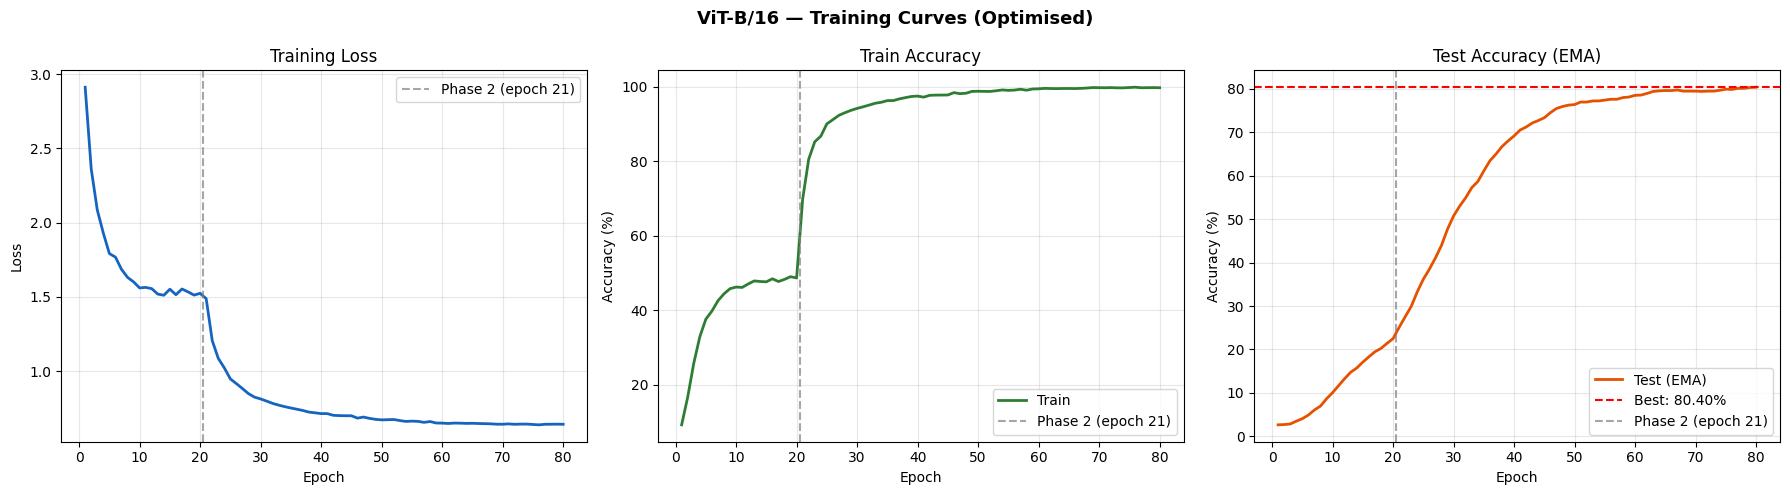

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ViT-B/16 — Training Curves (Optimised)', fontsize=13, fontweight='bold')

epochs     = range(1, NUM_EPOCHS + 1)
phase_line = dict(color='gray', linestyle='--', alpha=0.7, label=f'Phase 2 (epoch {WARMUP_EPOCHS+1})')

axes[0].plot(epochs, train_losses, '#1565C0', linewidth=2)
axes[0].axvline(WARMUP_EPOCHS + 0.5, **phase_line)
axes[0].set(xlabel='Epoch', ylabel='Loss', title='Training Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, train_accs, '#2E7D32', linewidth=2, label='Train')
axes[1].axvline(WARMUP_EPOCHS + 0.5, **phase_line)
axes[1].set(xlabel='Epoch', ylabel='Accuracy (%)', title='Train Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs, test_accs, '#E65100', linewidth=2, label='Test (EMA)')
axes[2].axhline(best_acc, color='red', linestyle='--', label=f'Best: {best_acc:.2f}%')
axes[2].axvline(WARMUP_EPOCHS + 0.5, **phase_line)
axes[2].set(xlabel='Epoch', ylabel='Accuracy (%)', title='Test Accuracy (EMA)')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
fig.savefig(root / 'Dataset/figures/vit_optimised_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8 — Evaluation

In [8]:
model.load_state_dict(torch.load(best_path, map_location=DEVICE, weights_only=True))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        preds = model(images.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
top1_acc   = (all_preds == all_labels).mean() * 100

print(f'Test Top-1 Accuracy (EMA) : {top1_acc:.2f}%')
print(f'ViT v1 (over-augmented)   : 65.25%')
print(f'MobileViT (reference)     : 74.60%')
print(f'Sayem et al. 2024 SOTA    : 83.11%')
print()
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=3))

Test Top-1 Accuracy (EMA) : 80.40%
ViT v1 (over-augmented)   : 65.25%
MobileViT (reference)     : 74.60%
Sayem et al. 2024 SOTA    : 83.11%

                         precision    recall  f1-score   support

            bottle-blue      0.772     0.750     0.761       104
       bottle-blue-full      0.721     0.721     0.721        43
          bottle-blue5l      0.800     0.778     0.789        72
     bottle-blue5l-full      0.882     0.625     0.732        24
            bottle-dark      0.871     0.926     0.898        95
       bottle-dark-full      0.806     0.853     0.829        34
           bottle-green      0.798     0.905     0.848        74
      bottle-green-full      0.833     0.882     0.857        34
            bottle-milk      0.776     0.789     0.783        57
       bottle-milk-full      0.792     0.905     0.844        21
      bottle-multicolor      0.667     0.429     0.522        28
bottle-multicolorv-full      0.765     0.619     0.684        21
             

## 9 — Confusion Matrix

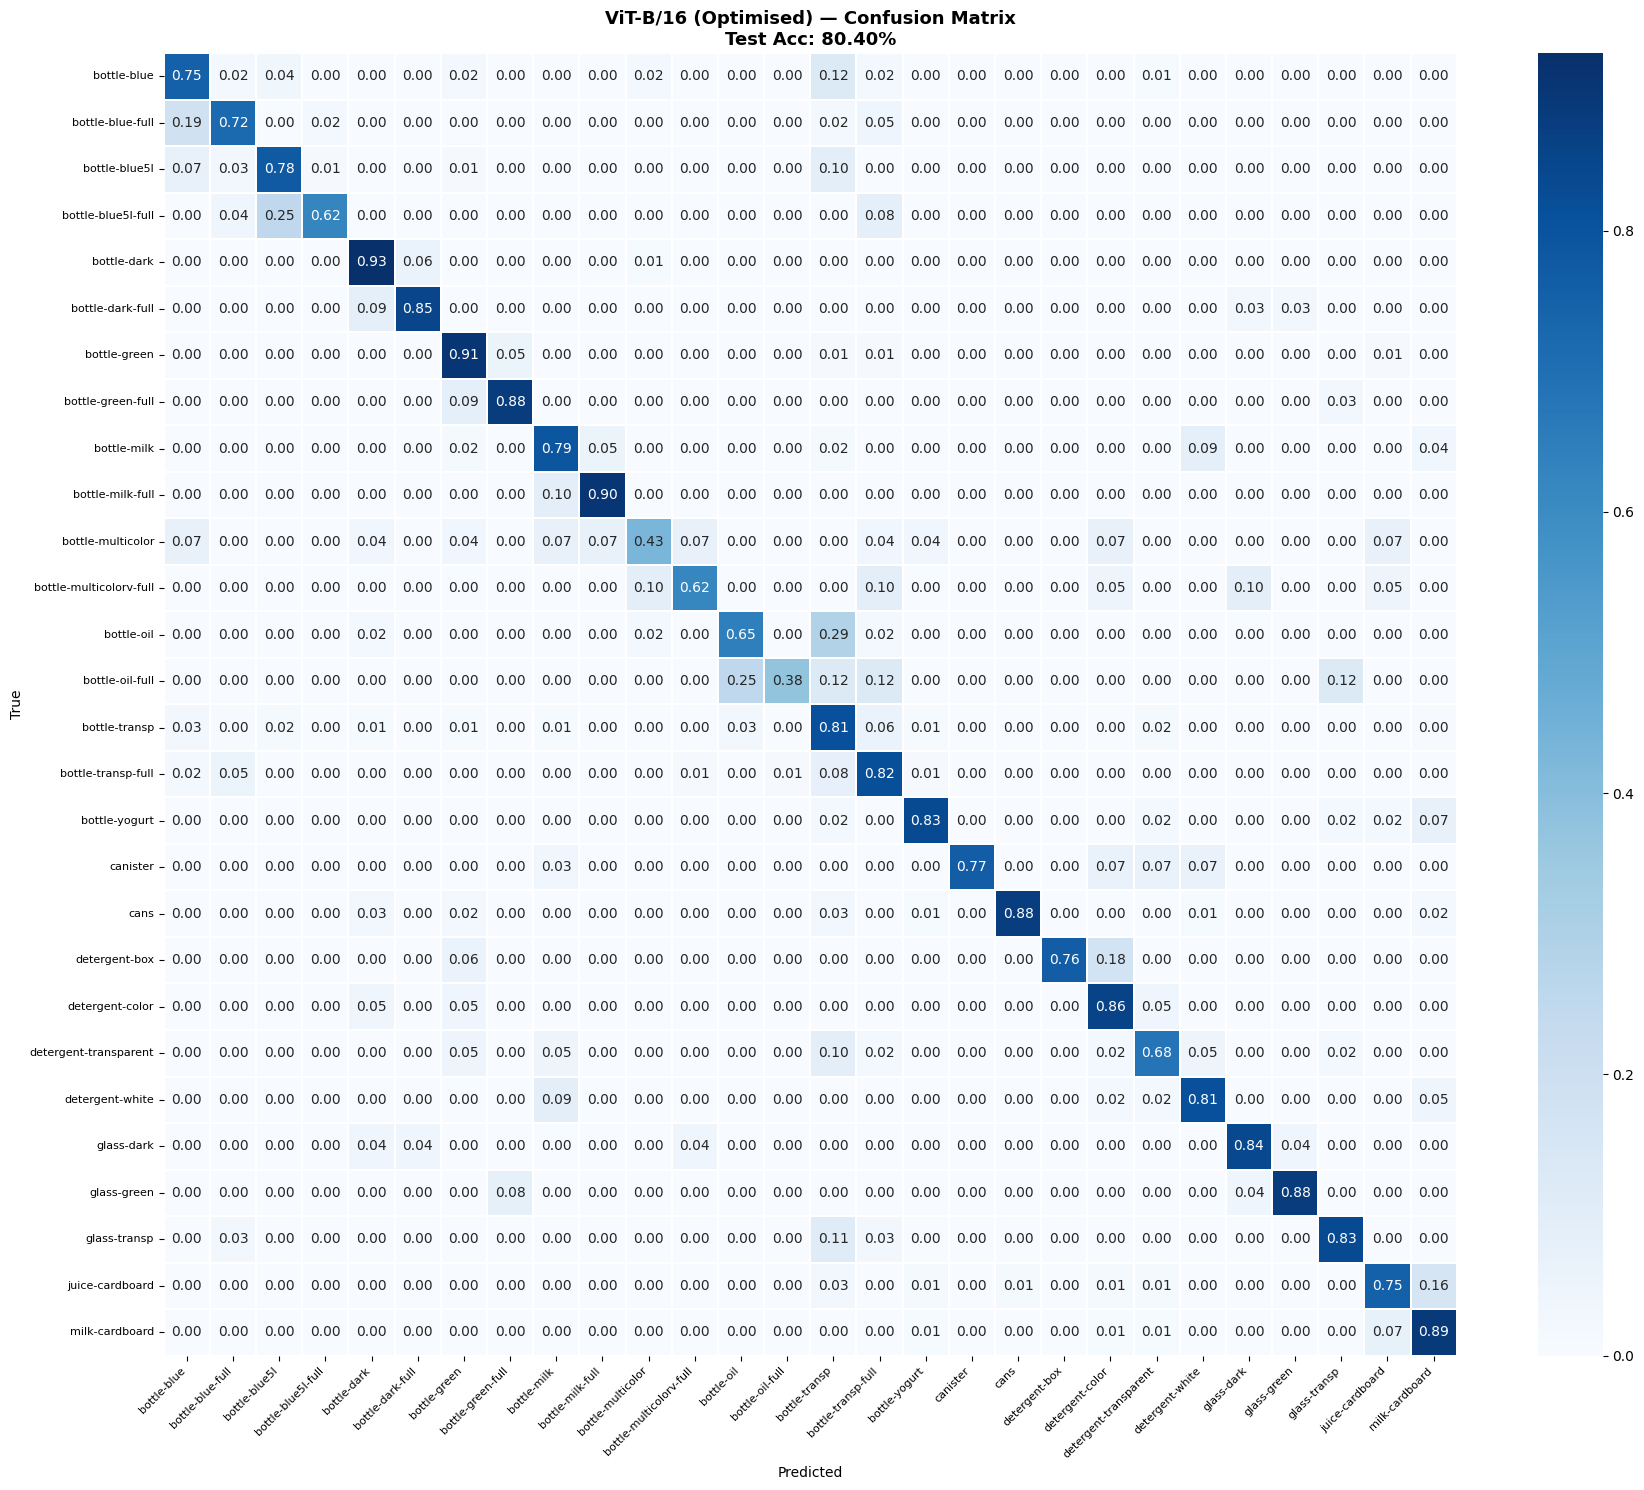

In [9]:
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.3, ax=ax)
ax.set_title(f'ViT-B/16 (Optimised) — Confusion Matrix\nTest Acc: {top1_acc:.2f}%',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
fig.savefig(root / 'Dataset/figures/vit_optimised_confusion.png', dpi=150, bbox_inches='tight')
plt.show()